# Measuring Galaxy Redshifts: Spectroscopic and Photometric Methods
## From simulated DESI spectra to EAZY-py photo-z estimation

**Templates:** qmost spectral templates (Comparat et al. 2020) — [github.com/JohanComparat/qmost_templates](https://github.com/JohanComparat/qmost_templates)  
**Spectroscopic z:** DESI / redrock algorithm — [github.com/desihub/redrock](https://github.com/desihub/redrock)  
**Photometric z:** EAZY-py — [github.com/gbrammer/eazy-py](https://github.com/gbrammer/eazy-py)

---

## Learning objectives

After this tutorial you will be able to:
1. Load real astrophysical **SED templates** (star-forming galaxy, quiescent galaxy, AGN type 1, AGN type 2) and simulate observed spectra at different redshifts.
2. **Rescale** a spectrum to a target apparent magnitude and **add realistic noise** at several SNR levels.
3. Compute synthetic **broadband photometry** (g, r, i) and its uncertainties from a noisy spectrum.
4. Understand how **redrock** measures spectroscopic redshifts on DESI spectra: template χ² fitting in log-wavelength space.
5. Understand how **EAZY-py** measures photometric redshifts: χ² minimisation over a template/redshift grid with a Bayesian P(z).
6. Compare the **precision and limitations** of spectroscopic vs. photometric redshifts as a function of SNR and galaxy type.

---

## 1. Background: why do we measure redshifts?

The **cosmological redshift** $z$ is the fundamental distance indicator in extragalactic astronomy:

$$z = \frac{\lambda_{\rm obs} - \lambda_0}{\lambda_0} = \frac{\lambda_{\rm obs}}{\lambda_0} - 1$$

A spectrum is observed at wavelengths shifted by a factor $(1+z)$ relative to the rest frame. Two independent methods are used in modern surveys:

| Method | Instrument | Precision | Cost |
|--------|-----------|-----------|------|
| **Spectroscopic** | spectrograph (e.g. DESI) | $\sigma_z \sim 0.001$ | telescope time per object |
| **Photometric** | imager (e.g. LSST, Euclid) | $\sigma_z \sim 0.02$–$0.10$ | simultaneous for millions |

DESI measures spectra for $\sim$40 million galaxies; Rubin/LSST will image $\sim$20 billion. Understanding the two methods, their complementarity, and their failures is essential for modern survey science.

---

## 2. Setup and imports

In [1]:
import os
import urllib.request
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import AutoMinorLocator

from astropy.io import fits
from astropy import units as u
from astropy import constants as const
from astropy.cosmology import FlatLambdaCDM
from scipy.stats import median_abs_deviation
from scipy.ndimage import gaussian_filter1d

# Optional: eazy-py for photometric redshifts
try:
    import eazy
    EAZY_AVAILABLE = True
    print('eazy-py is available.')
except ImportError:
    EAZY_AVAILABLE = False
    print('eazy-py not installed — using manual chi² photo-z implementation.')
    print('Install with: pip install eazy-py')

rng = np.random.default_rng(42)
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 13,
    'legend.fontsize': 11,
})

c_kms = const.c.to(u.km / u.s).value
print(f'Speed of light: {c_kms:.2f} km/s')

eazy-py is available.
Speed of light: 299792.46 km/s


---

## 3. Loading the qmost spectral templates

We use four empirical SED templates built from SDSS DR16 stacked spectra (Comparat et al. 2020). Each template is a **FITS binary table** with two columns:
- `LAMBDA` — rest-frame wavelength in Å (range 3000–11000 Å)
- `FLUX_DENSITY` — flux density in erg/s/cm²/Å, pre-normalised to apparent magnitude **r = 14** (HSC r-band)

| Label | File | Galaxy type |
|-------|------|-------------|
| ELG | `DR16_ELG-stitched-stack-qmost-template.fits` | Star-forming (Emission Line Galaxy) |
| LRG | `DR16LRG-stitched-stack-qmost-template.fits` | Quiescent (Luminous Red Galaxy) |
| AGN1 | `ROSAT_AGNT1-stitched-stack-qmost-template.fits` | AGN type 1 (broad lines) |
| AGN2 | `ROSAT_AGNT2-stitched-stack-qmost-template.fits` | AGN type 2 (narrow lines) |

Reference: Comparat et al. (2020) — [github.com/JohanComparat/qmost_templates](https://github.com/JohanComparat/qmost_templates)

In [2]:
# ── Download qmost templates (cached after first run) ─────────────────────────
CACHE_DIR = os.path.expanduser('~/.cache/tuto_stage_qmost')
os.makedirs(CACHE_DIR, exist_ok=True)

TEMPLATE_META = [
    ('ELG',  'DR16_ELG-stitched-stack-qmost-template.fits',          'Star-forming galaxy',  'steelblue'),
    ('LRG',  'DR16LRG-stitched-stack-qmost-template.fits',           'Quiescent galaxy',     'firebrick'),
    ('AGN1', 'ROSAT_AGNT1-stitched-stack-qmost-template.fits',       'AGN type 1',           'darkorange'),
    ('AGN2', 'ROSAT_AGNT2-stitched-stack-qmost-template.fits',       'AGN type 2',           'purple'),
]

BASE_URL = 'https://raw.githubusercontent.com/JohanComparat/qmost_templates/main/data/'

templates = {}   # dict: label -> {'wave': array, 'flux': array, 'color': str, 'label': str}

for (key, fname, description, color) in TEMPLATE_META:
    local_path = os.path.join(CACHE_DIR, fname)
    if not os.path.exists(local_path):
        url = BASE_URL + fname
        print(f'Downloading {fname} ...')
        try:
            urllib.request.urlretrieve(url, local_path)
            print(f'  Saved to {local_path}')
        except Exception as e:
            print(f'  Download failed: {e}')
            continue
    else:
        print(f'Using cached: {fname}')

    with fits.open(local_path) as hdul:
        data = hdul['SPECTRUM'].data
        wave = data['LAMBDA'].astype(float)
        flux = data['FLUX_DENSITY'].astype(float)

    # Keep only the useful wavelength range 3000–11000 Å
    mask = (wave >= 3000) & (wave <= 11000)
    templates[key] = {
        'wave'  : wave[mask],
        'flux'  : flux[mask],
        'color' : color,
        'label' : description,
    }
    print(f'  {key} ({description}): {mask.sum()} pixels, '
          f'λ = {wave[mask].min():.0f}–{wave[mask].max():.0f} Å')

Using cached: DR16_ELG-stitched-stack-qmost-template.fits
  ELG (Star-forming galaxy): 8598 pixels, λ = 3001–11000 Å
Using cached: DR16LRG-stitched-stack-qmost-template.fits
  LRG (Quiescent galaxy): 4087 pixels, λ = 3001–10975 Å
Using cached: ROSAT_AGNT1-stitched-stack-qmost-template.fits
  AGN1 (AGN type 1): 7852 pixels, λ = 3001–10999 Å
Using cached: ROSAT_AGNT2-stitched-stack-qmost-template.fits
  AGN2 (AGN type 2): 7048 pixels, λ = 3001–11000 Å


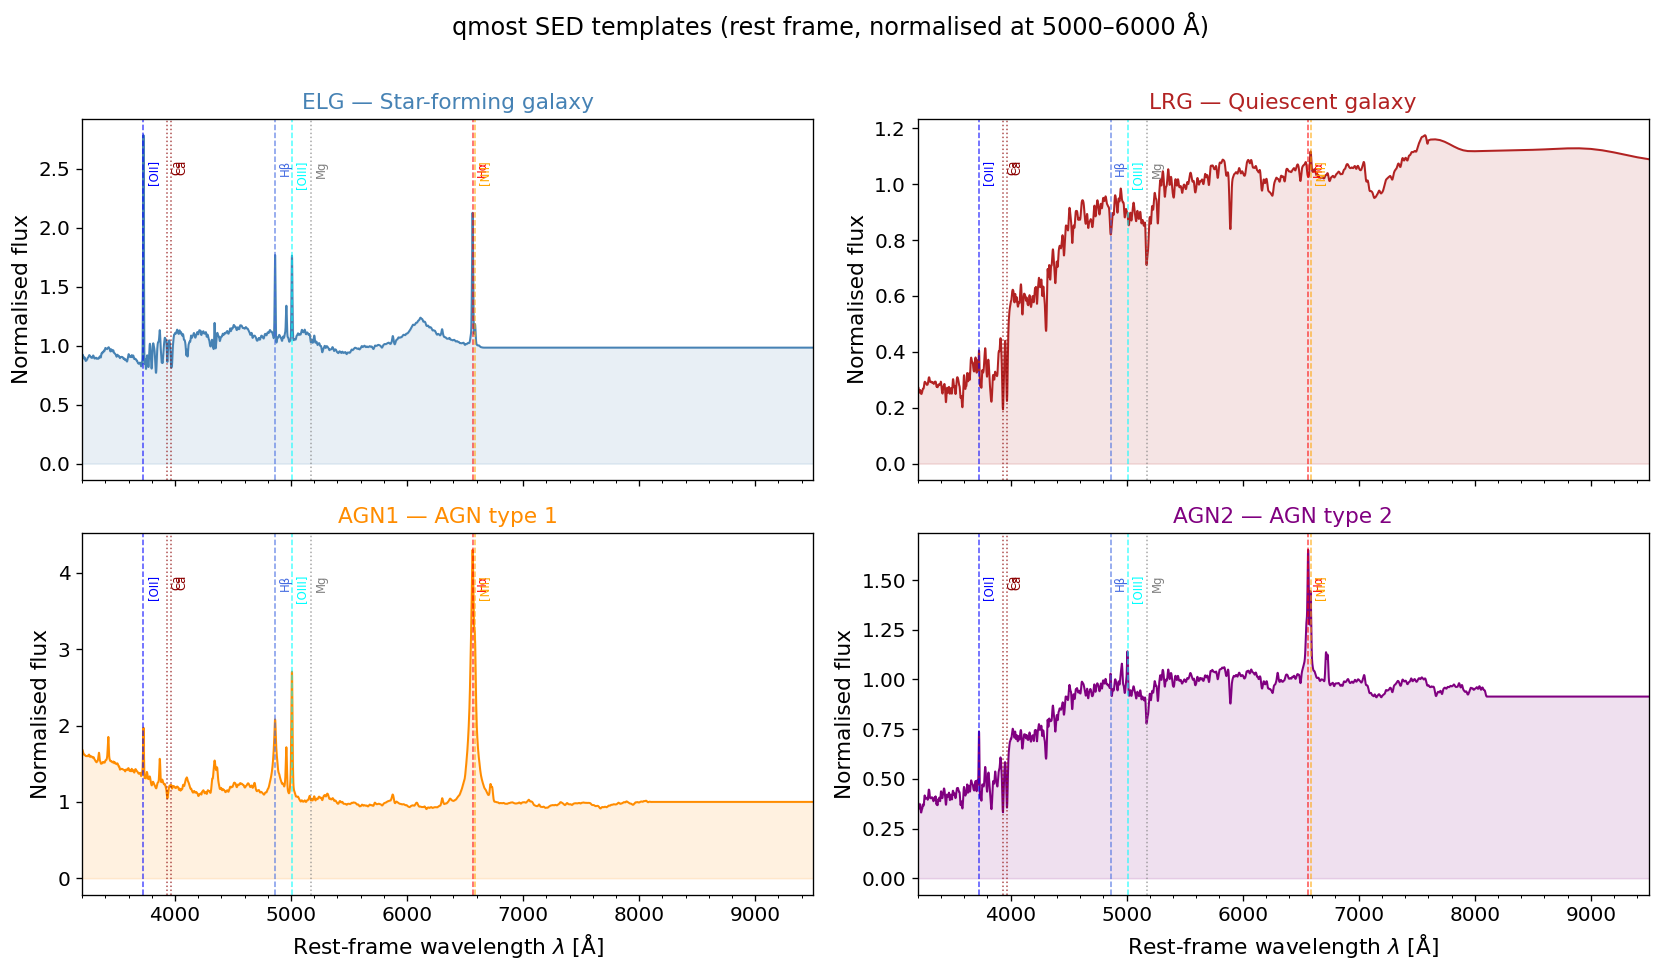

Figure saved: qmost_templates_restframe.png


In [3]:
# ── Plot rest-frame templates ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.ravel()

# Prominent spectral lines (vacuum wavelengths, Å)
LINES = {
    '[OII] 3727'  : (3727.1,  'blue',    'em'),
    'Ca K'        : (3934.8,  'darkred', 'abs'),
    'Ca H'        : (3969.6,  'darkred', 'abs'),
    'Hβ'          : (4862.7,  'royalblue','em'),
    '[OIII] 5007' : (5008.2,  'cyan',    'em'),
    'Mg b'        : (5176.7,  'gray',    'abs'),
    'Hα'          : (6564.6,  'red',     'em'),
    '[NII] 6583'  : (6585.3,  'orange',  'em'),
    'CIV 1549'    : (1549.5,  'indigo',  'em'),
    'MgII 2799'   : (2798.8,  'teal',    'em'),
    'CIII] 1909'  : (1908.7,  'navy',    'em'),
}

for ax, (key, tmpl) in zip(axes, templates.items()):
    wave = tmpl['wave']
    flux = tmpl['flux']
    smooth = gaussian_filter1d(flux, 3)
    norm   = np.nanmedian(smooth[(wave > 5000) & (wave < 6000)])
    norm   = norm if norm > 0 else 1.0
    ax.plot(wave, smooth / norm, color=tmpl['color'], lw=1.2)
    ax.fill_between(wave, 0, smooth / norm, alpha=0.12, color=tmpl['color'])
    # Mark spectral lines in the displayed range
    for lname, (lam0, lcolor, ltype) in LINES.items():
        if wave.min() < lam0 < wave.max():
            ls = '--' if ltype == 'em' else ':'
            ax.axvline(lam0, color=lcolor, lw=0.9, ls=ls, alpha=0.7)
            ax.text(lam0 + 30, ax.get_ylim()[1] * 0.88,
                    lname.split()[0], fontsize=7, color=lcolor,
                    rotation=90, va='top')
    ax.set_xlim(3200, 9500)
    ax.set_title(f'{key} — {tmpl["label"]}', color=tmpl['color'])
    ax.set_ylabel('Normalised flux')
    ax.xaxis.set_minor_locator(AutoMinorLocator())

for ax in axes[2:]:
    ax.set_xlabel('Rest-frame wavelength $\\lambda$ [Å]')

plt.suptitle('qmost SED templates (rest frame, normalised at 5000–6000 Å)', y=1.01)
plt.tight_layout()
plt.savefig('qmost_templates_restframe.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: qmost_templates_restframe.png')

---

## 4. Simulating observed spectra

### 4.1 Applying the cosmological redshift

Shifting a rest-frame spectrum to redshift $z$ is straightforward:
$$\lambda_{\rm obs} = \lambda_0 \,(1+z)$$

In $f_\lambda$ units (erg/s/cm²/Å), the flux density is divided by $(1+z)^2$ — one factor for the photon energy decrease and one for the bandwidth dilation (see e.g. [Hogg et al. 2002](https://arxiv.org/abs/astro-ph/0210394)). For a pedagogical normalisation, we apply the rescaling to a fixed apparent magnitude instead.

### 4.2 Rescaling to r = 20

We define SDSS-like g, r, i filter transmission curves as Gaussian approximations and compute the synthetic r-band flux by integrating the spectrum through the filter. Careful, this is not the True Filter Curve, but an ad-hoc function for the tutorial ! A scale factor maps the original r = 14 normalisation to r = 20:
$$a = 10^{(m_{\rm target} - m_0) / (-2.5)}$$

### 4.3 Adding noise

We add Gaussian noise at three levels: the noise amplitude per pixel is set so that the **SNR in the r-band** corresponds to 1%, 10%, or 50% relative flux uncertainty:
$$\sigma_{\rm pixel} = \varepsilon_r \times \langle F_r \rangle$$
where $\langle F_r \rangle$ is the median flux in the r-band window and $\varepsilon_r \in \{0.01, 0.10, 0.50\}$. Careful: in real observations, the true noise is much more complex, we simplify it for the purpose of the tutorial !

In [4]:
# ── SDSS filter definitions (Gaussian approximation) ─────────────────────────
# Effective wavelengths and FWHM from Fukugita et al. (1996)
FILTER_PARAMS = {
    'g': (4686., 1370.),   # (lambda_eff [Å], FWHM [Å])
    'r': (6166., 1400.),
    'i': (7480., 1530.),
}
BAND_COLORS = {'g': 'limegreen', 'r': 'firebrick', 'i': 'darkorange'}

def make_gaussian_filter(wave, lam_eff, fwhm):
    """Gaussian filter transmission curve, normalised to unit integral."""
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
    R = np.exp(-0.5 * ((wave - lam_eff) / sigma) ** 2)
    norm = np.trapezoid(R, wave)
    return R / norm if norm > 0 else R


def synthetic_flux_in_band(wave, flux, lam_eff, fwhm):
    """Compute the synthetic photon-weighted flux in a single band."""
    R = make_gaussian_filter(wave, lam_eff, fwhm)
    integrand = flux * R * wave      # photon-counting: multiply by lambda
    return np.trapezoid(integrand, wave)


def flux_to_abmag(flux_integrated, wave, lam_eff, fwhm):
    """Convert filter-integrated flux to AB magnitude (arbitrary zero-point offset)."""
    R = make_gaussian_filter(wave, lam_eff, fwhm)
    norm = np.trapezoid(R * wave, wave)
    f_nu = flux_integrated / norm if norm > 0 else np.nan
    if f_nu <= 0:
        return np.nan
    return -2.5 * np.log10(f_nu) + 23.9   # micro-Jansky zero-point


def rescale_to_rmag(wave, flux, target_rmag):
    """Scale the spectrum so that its r-band AB magnitude equals target_rmag."""
    lam_r, fwhm_r = FILTER_PARAMS['r']
    f_r_current = synthetic_flux_in_band(wave, flux, lam_r, fwhm_r)
    m_current   = flux_to_abmag(f_r_current, wave, lam_r, fwhm_r)
    if not np.isfinite(m_current):
        return flux
    scale = 10 ** ((m_current - target_rmag) / 2.5)
    return flux * scale


# Quick sanity check
tmpl = templates['ELG']
flux_20 = rescale_to_rmag(tmpl['wave'], tmpl['flux'], 20.0)
lam_r, fwhm_r = FILTER_PARAMS['r']
f_check = synthetic_flux_in_band(tmpl['wave'], flux_20, lam_r, fwhm_r)
m_check = flux_to_abmag(f_check, tmpl['wave'], lam_r, fwhm_r)
print(f'Sanity check — ELG rescaled to r=20: r_AB = {m_check:.3f} (target 20.000)')

Sanity check — ELG rescaled to r=20: r_AB = 20.000 (target 20.000)


In [5]:
# ── Generate all simulated observations ───────────────────────────────────────
Z_OBS       = [0.1, 0.3, 0.5]
NOISE_LEVELS = [0.01, 0.10, 0.50]   # sigma_r / F_r
TARGET_RMAG  = 20.0
TEMP_KEYS   = list(templates.keys())

# obs_catalog: list of dicts, one per (template, z, noise_level)
obs_catalog = []

for tkey in TEMP_KEYS:
    tmpl = templates[tkey]
    wave_rest = tmpl['wave']
    flux_rest = tmpl['flux']

    for z_true in Z_OBS:
        # Shift to observer frame: lambda_obs = lambda_rest * (1+z)
        wave_obs = wave_rest * (1.0 + z_true)
        # In f_lambda: divide by (1+z)^2 for proper K-correction, then rescale to r=20
        flux_obs_raw = flux_rest / (1.0 + z_true) ** 2
        flux_scaled  = rescale_to_rmag(wave_obs, flux_obs_raw, TARGET_RMAG)

        # Median flux level in r band (for setting noise scale)
        lam_r, fwhm_r = FILTER_PARAMS['r']
        sigma_r_band  = fwhm_r / (2 * np.sqrt(2 * np.log(2)))
        r_mask = np.abs(wave_obs - lam_r) < 1.5 * sigma_r_band
        f_r_median = np.median(flux_scaled[r_mask]) if r_mask.sum() > 5 else np.median(np.abs(flux_scaled))

        for noise_level in NOISE_LEVELS:
            sigma_pix = noise_level * f_r_median
            noise_arr = rng.normal(0.0, sigma_pix, size=len(flux_scaled))
            flux_noisy = flux_scaled + noise_arr

            # Inverse variance (ivar), assuming uniform noise per pixel
            ivar = np.full_like(flux_scaled, 1.0 / sigma_pix**2) if sigma_pix > 0 else np.ones_like(flux_scaled)

            obs_catalog.append({
                'template'    : tkey,
                'z_true'      : z_true,
                'noise_level' : noise_level,
                'wave'        : wave_obs,
                'flux'        : flux_noisy,
                'flux_clean'  : flux_scaled,
                'ivar'        : ivar,
                'sigma_pix'   : sigma_pix,
                'wave_rest'   : wave_rest,
                'flux_rest'   : flux_rest,
            })

print(f'Generated {len(obs_catalog)} simulated observations')
print(f'  = {len(TEMP_KEYS)} templates × {len(Z_OBS)} redshifts × {len(NOISE_LEVELS)} noise levels')

Generated 36 simulated observations
  = 4 templates × 3 redshifts × 3 noise levels


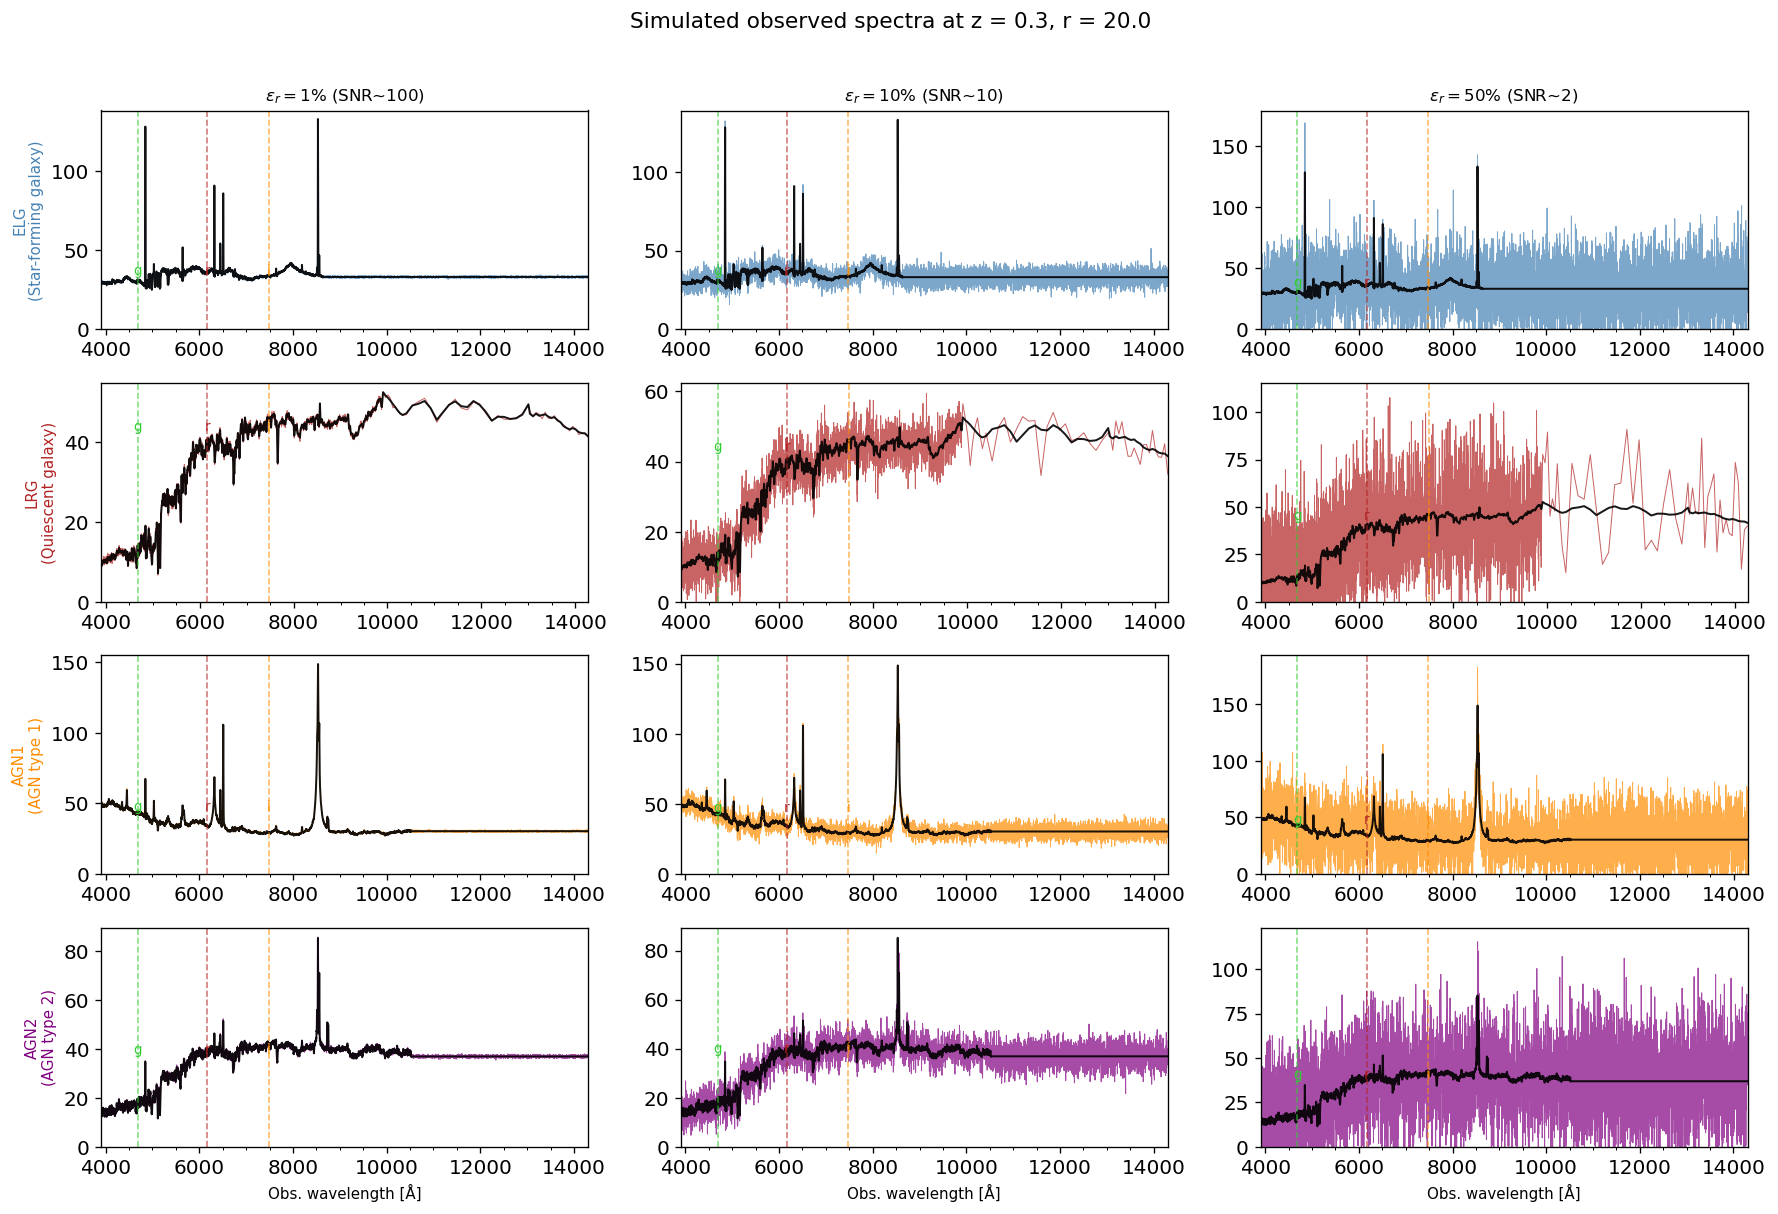

Figure saved: simulated_spectra_noise.png


In [6]:
# ── Plot: 4 templates × 3 noise levels at z=0.3 ───────────────────────────────
fig, axes = plt.subplots(len(TEMP_KEYS), len(NOISE_LEVELS),
                          figsize=(15, 10), sharex=False)

noise_labels = [f'$\\varepsilon_r={n*100:.0f}$% (SNR~{int(1/n)})' for n in NOISE_LEVELS]

for row, tkey in enumerate(TEMP_KEYS):
    for col, noise_level in enumerate(NOISE_LEVELS):
        # Find the observation at z=0.3 for this template and noise level
        entry = next(e for e in obs_catalog
                     if e['template'] == tkey
                     and e['z_true'] == 0.3
                     and e['noise_level'] == noise_level)
        ax = axes[row][col]
        color = templates[tkey]['color']
        wave  = entry['wave']
        flux  = entry['flux']
        clean = entry['flux_clean']

        ax.plot(wave, flux,  color=color, lw=0.6, alpha=0.7)
        ax.plot(wave, clean, color='black', lw=1.2, alpha=0.9, label='noise-free')

        # Mark filter band centres
        ymax = np.nanpercentile(clean, 95)
        for band, (leff, _) in FILTER_PARAMS.items():
            ax.axvline(leff, color=BAND_COLORS[band], lw=1.0, ls='--', alpha=0.6)
            ax.text(leff, ymax * 0.92, band, color=BAND_COLORS[band],
                    fontsize=8, ha='center')

        ax.set_xlim(wave.min(), wave.max())
        ax.set_ylim(bottom=0)
        ax.xaxis.set_minor_locator(AutoMinorLocator())

        if row == 0:
            ax.set_title(noise_labels[col], fontsize=10)
        if col == 0:
            ax.set_ylabel(f'{tkey}\n({templates[tkey]["label"]})', fontsize=9, color=color)
        if row == len(TEMP_KEYS) - 1:
            ax.set_xlabel('Obs. wavelength [Å]', fontsize=9)

plt.suptitle(f'Simulated observed spectra at z = 0.3, r = {TARGET_RMAG}', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('simulated_spectra_noise.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: simulated_spectra_noise.png')

---

## 5. Synthetic broadband photometry (g, r, i)

Integrating the noisy spectrum through each filter gives the synthetic broadband fluxes. The uncertainty on the integrated flux is propagated from the per-pixel noise:

$$f_b = \int F(\lambda)\, R_b(\lambda)\, \lambda\, d\lambda \qquad
\sigma_{f_b} = \sigma_{\rm pixel} \sqrt{\int R_b^2(\lambda)\, \lambda^2\, d\lambda}$$

where the $\lambda$ weighting converts from $f_\lambda$ to photon-count units.

In [7]:
def compute_photometry(wave, flux, sigma_pix):
    """
    Compute synthetic g, r, i fluxes and 1-sigma uncertainties.

    Returns dict: {band: (flux_int, sigma_flux_int)}
    """
    phot = {}
    for band, (leff, fwhm) in FILTER_PARAMS.items():
        R    = make_gaussian_filter(wave, leff, fwhm)
        kern = R * wave   # photon-counting kernel
        dlam = np.gradient(wave)
        f_b  = np.sum(flux * kern * dlam)
        # Error: sigma_pix * sqrt(sum(kern^2 * dlam^2))
        sigma_b = sigma_pix * np.sqrt(np.sum((kern * dlam) ** 2))
        phot[band] = (f_b, sigma_b)
    return phot


# Compute photometry for every observation and store in catalog
for entry in obs_catalog:
    entry['phot'] = compute_photometry(entry['wave'], entry['flux'], entry['sigma_pix'])

# ── Display a summary table ───────────────────────────────────────────────────
print(f'{"Template":<6} {"z":>5} {"noise":>8}  {"m_g":>7} {"m_r":>7} {"m_i":>7}  '
      f'{"σ_r/F_r":>9}')
print('-' * 65)

leff_r, fwhm_r = FILTER_PARAMS['r']
norm_r = None

for entry in obs_catalog:
    phot  = entry['phot']
    wave  = entry['wave']
    t     = entry['template']
    z     = entry['z_true']
    nl    = entry['noise_level']

    mags = {}
    snrs = {}
    for band in ['g', 'r', 'i']:
        f_b, sf_b = phot[band]
        mags[band] = flux_to_abmag(f_b, wave, *FILTER_PARAMS[band])
        snrs[band] = abs(f_b / sf_b) if sf_b > 0 else np.inf

    entry['mags'] = mags
    entry['snrs'] = snrs

    if nl == 0.10:   # print only the middle noise level to keep table short
        print(f'{t:<6} {z:>5.1f} {nl:>8.0%}  '
              f'{mags["g"]:>7.2f} {mags["r"]:>7.2f} {mags["i"]:>7.2f}  '
              f'{1/snrs["r"]:>8.1%}')

Template     z    noise      m_g     m_r     m_i    σ_r/F_r
-----------------------------------------------------------------
ELG      0.1      10%    20.00   20.00   20.03      0.3%
ELG      0.3      10%    20.12   20.00   20.03      0.3%
ELG      0.5      10%    20.15   20.00   19.97      0.3%
LRG      0.1      10%    20.44   20.00   19.94      0.3%
LRG      0.3      10%    20.85   20.00   19.81      0.3%
LRG      0.5      10%    20.78   20.00   19.52      0.3%
AGN1     0.1      10%    19.83   20.00   19.96      0.2%
AGN1     0.3      10%    19.84   20.00   20.13      0.3%
AGN1     0.5      10%    19.78   20.00   20.08      0.3%
AGN2     0.1      10%    20.30   20.00   19.99      0.3%
AGN2     0.3      10%    20.61   20.00   19.89      0.3%
AGN2     0.5      10%    20.56   20.00   19.66      0.3%


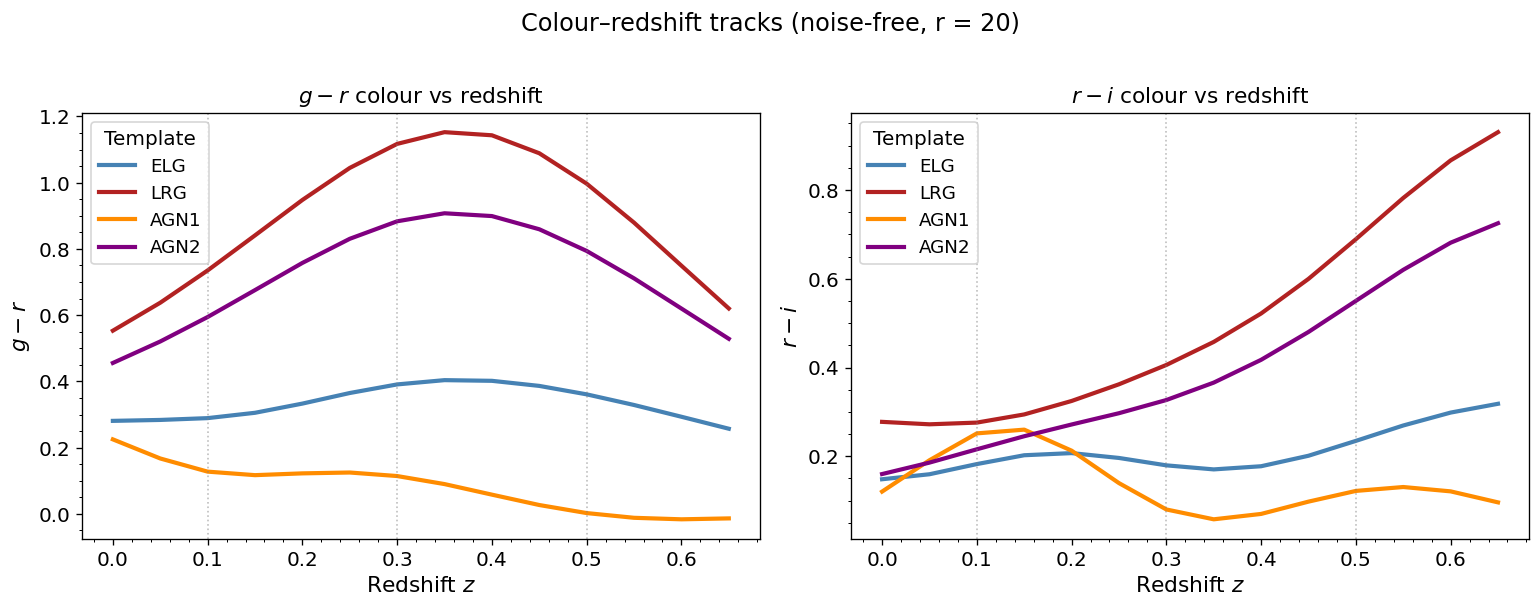

In [8]:
# ── Colour–redshift tracks ────────────────────────────────────────────────────
# Compute g-r and r-i for the CLEAN (noise-free) spectra as a function of z
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

Z_FINE = np.arange(0.0, 0.7, 0.05)

for tkey, tmpl in templates.items():
    gr_track, ri_track = [], []
    for z_val in Z_FINE:
        wave_z = tmpl['wave'] * (1 + z_val)
        flux_z = tmpl['flux'] / (1 + z_val) ** 2
        flux_z = rescale_to_rmag(wave_z, flux_z, TARGET_RMAG)
        phot   = compute_photometry(wave_z, flux_z, 0.0)   # noise-free
        f_g = phot['g'][0]
        f_r = phot['r'][0]
        f_i = phot['i'][0]
        if f_g > 0 and f_r > 0 and f_i > 0:
            gr_track.append(-2.5 * np.log10(f_g / f_r))
            ri_track.append(-2.5 * np.log10(f_r / f_i))
        else:
            gr_track.append(np.nan)
            ri_track.append(np.nan)
    axes[0].plot(Z_FINE, gr_track, color=tmpl['color'], lw=2.5, label=tkey)
    axes[1].plot(Z_FINE, ri_track, color=tmpl['color'], lw=2.5, label=tkey)

for ax, ylabel, title in zip(axes, ['$g-r$', '$r-i$'],
                               ['$g-r$ colour vs redshift', '$r-i$ colour vs redshift']):
    ax.set_xlabel('Redshift $z$')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(title='Template')
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    for z_obs in Z_OBS:
        ax.axvline(z_obs, color='gray', ls=':', lw=1, alpha=0.5)

plt.suptitle('Colour–redshift tracks (noise-free, r = 20)', y=1.01)
plt.tight_layout()
plt.savefig('color_redshift_tracks_qmost.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 6. Spectroscopic redshift measurement — the redrock algorithm

### 6.1 How redrock works

**redrock** is the primary redshift fitting code for DESI. Its key steps are:

1. **Template library** — templates are decomposed into a small set of PCA eigenvectors. This compresses the template diversity into a low-dimensional basis.
2. **Log-wavelength grid** — both data and templates are rebinned onto a uniform grid in $\ln\lambda$. Shifting in redshift corresponds to a *translation* on this grid, enabling efficient cross-correlation.
3. **χ² fitting** — for each redshift $z$ on a fine grid, the templates are shifted and the best-fit normalisation $a$ is solved analytically:
   $$a = \frac{\sum_i F_i^{\rm obs}\, T_i^z / \sigma_i^2}{\sum_i (T_i^z)^2 / \sigma_i^2}$$
   then:
   $$\chi^2(z) = \sum_i \frac{(F_i^{\rm obs} - a\, T_i^z)^2}{\sigma_i^2}$$
4. **Best-fit** — the $z$ minimising $\chi^2$ is reported together with a `ZWARN` bitmask flagging suspicious fits.

References: [github.com/desihub/redrock](https://github.com/desihub/redrock) | [data.desi.lbl.gov/doc/](https://data.desi.lbl.gov/doc/) | [desihub/tutorials](https://github.com/desihub/tutorials)

### 6.2 Simplified implementation

Below we implement the core χ² fitting algorithm pedagogically, using the four qmost templates as the template library.

In [9]:
# ── Template chi² fitting (spectroscopic redshift) ────────────────────────────

Z_SPEC_GRID = np.linspace(0.0, 0.70, 700)   # redshift search grid

def spec_chi2_at_z(obs_wave, obs_flux, obs_ivar,
                   tmpl_wave_rest, tmpl_flux_rest, z):
    """
    Compute chi² for a single (template, z) combination.

    The template is redshifted to z, interpolated onto the observed wavelength
    grid, and the best-fit amplitude is solved analytically.
    """
    tmpl_wave_obs = tmpl_wave_rest * (1.0 + z)
    tmpl_interp   = np.interp(obs_wave, tmpl_wave_obs, tmpl_flux_rest,
                               left=0.0, right=0.0)
    good = (obs_ivar > 0) & np.isfinite(obs_flux) & (tmpl_interp > 0)
    if good.sum() < 20:
        return np.inf, 0.0
    w  = obs_ivar[good]
    F  = obs_flux[good]
    T  = tmpl_interp[good]
    # Analytic best-fit normalisation
    num = np.sum(w * F * T)
    den = np.sum(w * T * T)
    if den <= 0:
        return np.inf, 0.0
    a    = num / den
    resid = F - a * T
    chi2  = np.sum(w * resid ** 2)
    return chi2, a


def fit_spectroscopic_redshift(obs_wave, obs_flux, obs_ivar,
                                z_grid=Z_SPEC_GRID):
    """
    Find the best-fit spectroscopic redshift by scanning all templates.

    Returns: z_best, tmpl_best, chi2_curve dict, chi2_min
    """
    best_chi2  = np.inf
    best_z     = np.nan
    best_tmpl  = None
    chi2_curves = {}

    for tkey, tmpl in templates.items():
        chi2_arr = np.array([
            spec_chi2_at_z(obs_wave, obs_flux, obs_ivar,
                           tmpl['wave'], tmpl['flux'], z)[0]
            for z in z_grid
        ])
        chi2_curves[tkey] = chi2_arr
        idx_min = np.argmin(chi2_arr)
        if chi2_arr[idx_min] < best_chi2:
            best_chi2 = chi2_arr[idx_min]
            best_z    = z_grid[idx_min]
            best_tmpl = tkey

    return best_z, best_tmpl, chi2_curves, best_chi2


print('Running spectroscopic redshift fitting on all observations...')
spec_results = []
for entry in obs_catalog:
    z_fit, t_fit, chi2_curves, chi2_min = fit_spectroscopic_redshift(
        entry['wave'], entry['flux'], entry['ivar']
    )
    dz = z_fit - entry['z_true']
    spec_results.append({
        'template'    : entry['template'],
        'z_true'      : entry['z_true'],
        'noise_level' : entry['noise_level'],
        'z_spec'      : z_fit,
        'tmpl_fit'    : t_fit,
        'dz'          : dz,
        'dz_norm'     : dz / (1 + entry['z_true']),
        'chi2_min'    : chi2_min,
        'chi2_curves' : chi2_curves,
    })

print(f'Done. {len(spec_results)} fits completed.')

# ── Summary table ──────────────────────────────────────────────────────────────
print(f'\n{"Template":<8} {"Noise":>7}  {"z_true":>7} {"z_fit":>7}  {"Δz/(1+z)":>12}  {"OK?"}')
print('-' * 58)
for res in spec_results:
    ok = 'YES' if abs(res['dz_norm']) < 0.01 else 'FAIL'
    print(f'{res["template"]:<8} {res["noise_level"]:>7.0%}  '
          f'{res["z_true"]:>7.3f} {res["z_spec"]:>7.3f}  '
          f'{res["dz_norm"]:>+12.5f}  {ok}')
print('-' * 58)
n_ok = sum(1 for r in spec_results if abs(r['dz_norm']) < 0.01)
print(f'Success rate: {n_ok}/{len(spec_results)} ({100*n_ok/len(spec_results):.0f}%)')

Running spectroscopic redshift fitting on all observations...


Done. 36 fits completed.

Template   Noise   z_true   z_fit      Δz/(1+z)  OK?
----------------------------------------------------------
ELG           1%    0.100   0.100      +0.00013  YES
ELG          10%    0.100   0.100      +0.00013  YES
ELG          50%    0.100   0.700      +0.54545  FAIL
ELG           1%    0.300   0.300      +0.00033  YES
ELG          10%    0.300   0.300      +0.00033  YES
ELG          50%    0.300   0.000      -0.23077  FAIL
ELG           1%    0.500   0.500      -0.00019  YES
ELG          10%    0.500   0.500      -0.00019  YES
ELG          50%    0.500   0.000      -0.33333  FAIL
LRG           1%    0.100   0.100      +0.00013  YES
LRG          10%    0.100   0.100      +0.00013  YES
LRG          50%    0.100   0.700      +0.54545  FAIL
LRG           1%    0.300   0.300      +0.00033  YES
LRG          10%    0.300   0.300      +0.00033  YES
LRG          50%    0.300   0.693      +0.30230  FAIL
LRG           1%    0.500   0.500      -0.00019  YES
LRG      

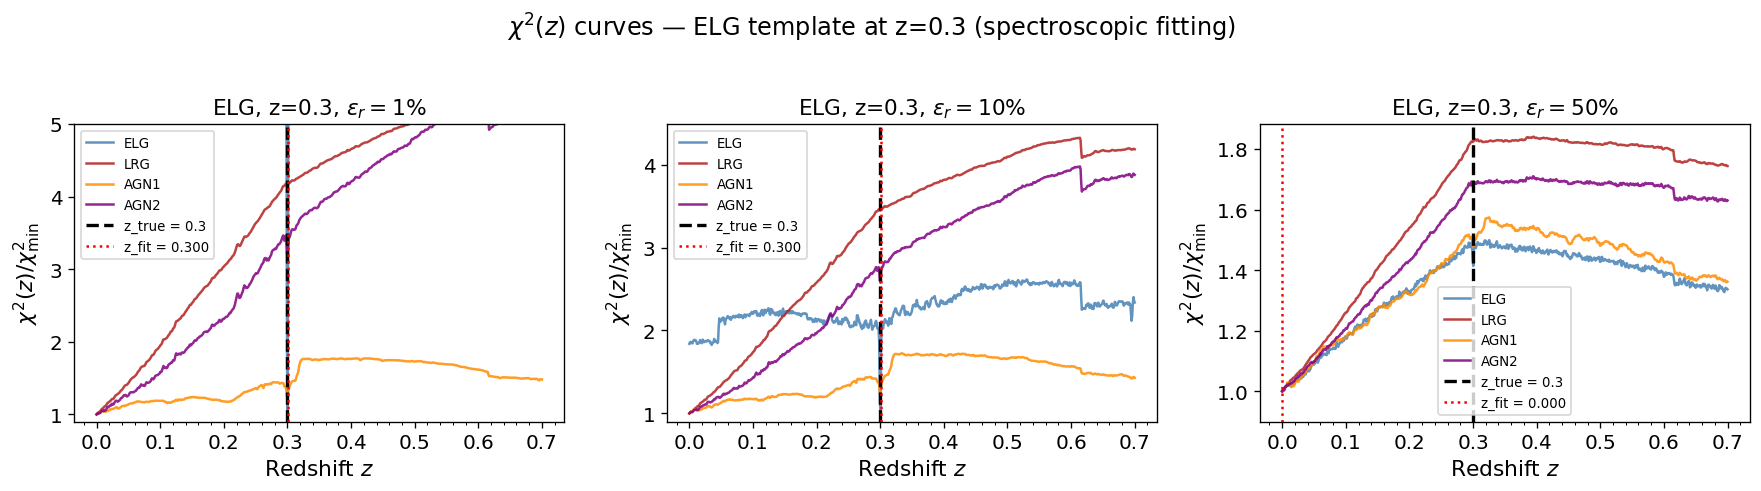

Figure saved: spec_chi2_curves.png


In [10]:
# ── Plot: chi²(z) curves for one spectrum at all three noise levels ────────────
# Show ELG at z=0.3 as example
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for col, noise_level in enumerate(NOISE_LEVELS):
    res = next(r for r in spec_results
               if r['template'] == 'ELG'
               and r['z_true'] == 0.3
               and r['noise_level'] == noise_level)
    ax = axes[col]
    for tkey, tmpl in templates.items():
        c2 = res['chi2_curves'][tkey]
        c2_norm = c2 / c2.min()   # normalise to minimum
        ax.plot(Z_SPEC_GRID, c2_norm, color=tmpl['color'], lw=1.5,
                label=tkey, alpha=0.85)
    ax.axvline(0.3, color='black', lw=2, ls='--', label='z_true = 0.3')
    ax.axvline(res['z_spec'], color='red', lw=1.5, ls=':', label=f"z_fit = {res['z_spec']:.3f}")
    ax.set_xlabel('Redshift $z$')
    ax.set_ylabel('$\\chi^2(z) / \\chi^2_{\\min}$')
    ax.set_title(f'ELG, z=0.3, $\\varepsilon_r={noise_level*100:.0f}$%')
    ax.set_ylim(0.9, min(5.0, ax.get_ylim()[1]))
    ax.legend(fontsize=8)
    ax.xaxis.set_minor_locator(AutoMinorLocator())

plt.suptitle('$\\chi^2(z)$ curves — ELG template at z=0.3 (spectroscopic fitting)', y=1.02)
plt.tight_layout()
plt.savefig('spec_chi2_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: spec_chi2_curves.png')

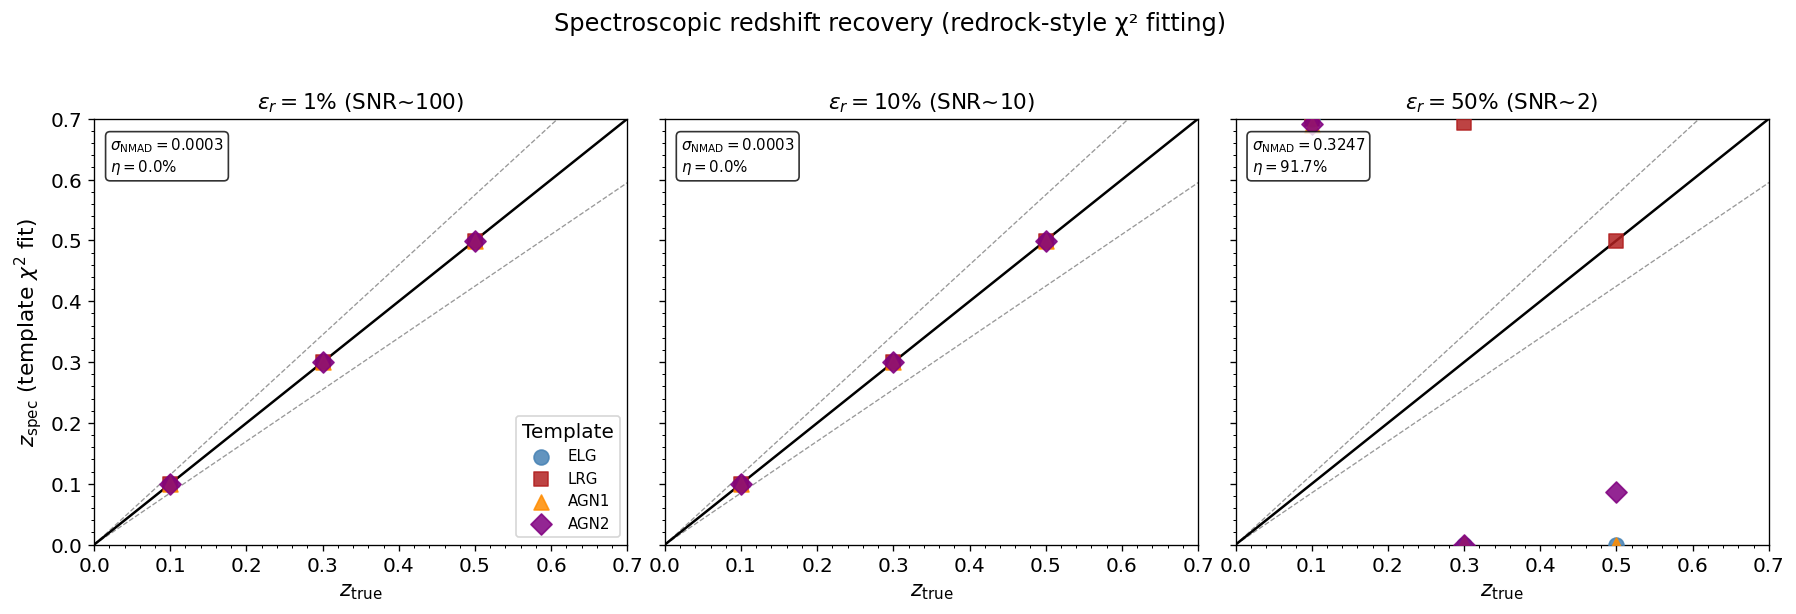

In [11]:
# ── Scatter plot: z_spec vs z_true, coloured by noise level ───────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True, sharex=True)

noise_colors = {0.01: 'limegreen', 0.10: 'darkorange', 0.50: 'firebrick'}
markers      = {'ELG': 'o', 'LRG': 's', 'AGN1': '^', 'AGN2': 'D'}

for col, noise_level in enumerate(NOISE_LEVELS):
    ax = axes[col]
    subset = [r for r in spec_results if r['noise_level'] == noise_level]
    for res in subset:
        ax.scatter(res['z_true'], res['z_spec'],
                   color=templates[res['template']]['color'],
                   marker=markers[res['template']],
                   s=80, alpha=0.85, zorder=3,
                   label=res['template'])

    z_diag = [0, 0.75]
    ax.plot(z_diag, z_diag, 'k-', lw=1.5)
    ax.plot(z_diag, [z*(1.15) for z in z_diag], 'k--', lw=0.8, alpha=0.4)
    ax.plot(z_diag, [z*(0.85) for z in z_diag], 'k--', lw=0.8, alpha=0.4)
    ax.set_xlabel('$z_{\\rm true}$')
    ax.set_title(f'$\\varepsilon_r = {noise_level*100:.0f}$% (SNR~{int(1/noise_level)})')
    ax.set_xlim(0, 0.7)
    ax.set_ylim(0, 0.7)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())

    dz_norm = np.array([r['dz_norm'] for r in subset])
    nmad    = 1.4826 * median_abs_deviation(dz_norm)
    eta     = np.mean(np.abs(dz_norm) > 0.15)
    ax.text(0.03, 0.96, f'$\\sigma_{{\\rm NMAD}}={nmad:.4f}$\n$\\eta={eta*100:.1f}\\%$',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round', fc='white', alpha=0.8))

axes[0].set_ylabel('$z_{\\rm spec}$ (template $\\chi^2$ fit)')
# De-duplicate legend entries
handles, labels_leg = axes[0].get_legend_handles_labels()
seen = set()
h2, l2 = [], []
for h, l in zip(handles, labels_leg):
    if l not in seen:
        h2.append(h); l2.append(l); seen.add(l)
axes[0].legend(h2, l2, title='Template', fontsize=9)

plt.suptitle('Spectroscopic redshift recovery (redrock-style χ² fitting)', y=1.02)
plt.tight_layout()
plt.savefig('spec_z_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
# ── Summary table: spectroscopic z accuracy ───────────────────────────────────
print('=' * 70)
print(f'{"Template":<8} {"Noise":>8}  {"z_true":>7} {"z_fit":>7}  {"Δz/(1+z)":>12}  {"Correct?"}')
print('-' * 70)
for res in spec_results:
    ok = '✓ YES' if abs(res['dz_norm']) < 0.01 else '✗ FAIL'
    print(f'{res["template"]:<8} {res["noise_level"]:>8.0%}  '
          f'{res["z_true"]:>7.3f} {res["z_spec"]:>7.3f}  '
          f'{res["dz_norm"]:>+12.5f}  {ok}')
print('=' * 70)
print('Note: Δz/(1+z) < 0.01 ≈ "correct" for a pedagogical threshold.')
print('      Real DESI uses |Δv| = c|Δz|/(1+z) < 1000 km/s.')

Template    Noise   z_true   z_fit      Δz/(1+z)  Correct?
----------------------------------------------------------------------
ELG            1%    0.100   0.100      +0.00013  ✓ YES
ELG           10%    0.100   0.100      +0.00013  ✓ YES
ELG           50%    0.100   0.700      +0.54545  ✗ FAIL
ELG            1%    0.300   0.300      +0.00033  ✓ YES
ELG           10%    0.300   0.300      +0.00033  ✓ YES
ELG           50%    0.300   0.000      -0.23077  ✗ FAIL
ELG            1%    0.500   0.500      -0.00019  ✓ YES
ELG           10%    0.500   0.500      -0.00019  ✓ YES
ELG           50%    0.500   0.000      -0.33333  ✗ FAIL
LRG            1%    0.100   0.100      +0.00013  ✓ YES
LRG           10%    0.100   0.100      +0.00013  ✓ YES
LRG           50%    0.100   0.700      +0.54545  ✗ FAIL
LRG            1%    0.300   0.300      +0.00033  ✓ YES
LRG           10%    0.300   0.300      +0.00033  ✓ YES
LRG           50%    0.300   0.693      +0.30230  ✗ FAIL
LRG            1%    0.50

### 6.3 Real redrock on DESI data

The real `redrock` code operates on DESI-format coadd FITS files. The basic workflow is:

```bash
# Install (requires DESI software stack)
# pip install redrock

# Run on a DESI coadd file
# rrdesi --input coadd-sv3-bright-9921.fits \
#        --output zbest-sv3-bright-9921.fits \
#        --templates $RR_TEMPLATE_DIR
```

The output `zbest` file contains for each fiber:
- `Z` — best-fit redshift
- `ZERR` — redshift uncertainty
- `ZWARN` — bitmask (0 = reliable; non-zero = use with caution)
- `CHI2` — minimum χ²
- `SPECTYPE` — best-fit type (GALAXY, QSO, STAR)

See the DESI documentation at [data.desi.lbl.gov/doc/](https://data.desi.lbl.gov/doc/) and tutorial notebooks at [github.com/desihub/tutorials](https://github.com/desihub/tutorials).

---

## 7. Photometric redshift measurement — EAZY-py

### 7.1 How EAZY-py works

**EAZY** (Easy and Accurate photo-Z from Yale) is a template-fitting photo-z code (Brammer, van Dokkum & Coppi 2008). **eazy-py** is its Python implementation.

Given broadband fluxes $f_b$ with uncertainties $\sigma_b$ in filters $b$, the algorithm:

1. **Template library** — a set of galaxy SED templates $T_t(\lambda)$.
2. **Predicted fluxes** — for each template $t$ and redshift $z$:
   $$F_b^{\rm pred}(z, t) = \int T_t\!\left(\frac{\lambda}{1+z}\right) R_b(\lambda)\, \lambda\, d\lambda$$
3. **χ² minimisation** — the best-fit amplitude is solved analytically (same formula as for spectroscopic z), giving:
   $$\chi^2(z, t) = \sum_b \frac{(f_b - a_{z,t}\, F_b^{\rm pred})^2}{\sigma_b^2}$$
4. **P(z) posterior** — summing over templates with a prior $\pi(z)$:
   $$P(z) \propto \pi(z)\, \sum_t \exp\!\left(-\frac{\chi^2(z,t)}{2}\right)$$
5. **Template error function** — an additional term $\sigma_t(\lambda)$ accounts for template mismatch.

References: Brammer et al. (2008), ApJ 686, 1503. [arXiv:0807.1533](https://arxiv.org/abs/0807.1533)  
eazy-py documentation: [eazy-py.readthedocs.io](https://eazy-py.readthedocs.io)

### 7.2 Manual implementation

We implement the core χ² fitting using our qmost template library and the g, r, i photometry from Section 5.

In [13]:
# ── Precompute model photometry grid: shape (N_templates, N_z, N_bands) ────────
Z_PHOT_GRID = np.arange(0.0, 0.75, 0.01)
BANDS_USE   = ['g', 'r', 'i']

N_t = len(TEMP_KEYS)
N_z = len(Z_PHOT_GRID)
N_b = len(BANDS_USE)

# grid_model[it, iz, ib] = predicted flux in band ib for template it at redshift Z_PHOT_GRID[iz]
grid_model = np.zeros((N_t, N_z, N_b))

for it, tkey in enumerate(TEMP_KEYS):
    tmpl = templates[tkey]
    for iz, z_val in enumerate(Z_PHOT_GRID):
        wave_z = tmpl['wave'] * (1.0 + z_val)
        flux_z = tmpl['flux'] / (1.0 + z_val) ** 2
        for ib, band in enumerate(BANDS_USE):
            leff, fwhm = FILTER_PARAMS[band]
            grid_model[it, iz, ib] = synthetic_flux_in_band(wave_z, flux_z, leff, fwhm)

print(f'Model photometry grid: shape {grid_model.shape} — (templates × z_grid × bands)')


def photoz_chi2_grid(obs_fluxes, obs_errors, model_grid, z_grid):
    """
    Compute χ²(z) by scanning templates and redshifts.

    Parameters
    ----------
    obs_fluxes  : (N_b,) array — observed fluxes in g, r, i
    obs_errors  : (N_b,) array — 1-sigma flux uncertainties
    model_grid  : (N_t, N_z, N_b) array — predicted model fluxes
    z_grid      : (N_z,) array

    Returns
    -------
    z_phot  : best-fit photometric redshift
    t_phot  : best-fit template key
    pz      : P(z) array (normalised)
    chi2_best : minimum chi²
    """
    w   = 1.0 / obs_errors ** 2
    N_t_loc, N_z_loc, N_b_loc = model_grid.shape

    chi2_full = np.full((N_t_loc, N_z_loc), np.inf)

    for it in range(N_t_loc):
        for iz in range(N_z_loc):
            T = model_grid[it, iz, :]   # predicted fluxes in g, r, i
            num = np.sum(w * obs_fluxes * T)
            den = np.sum(w * T * T)
            if den <= 0:
                continue
            a = num / den
            if a <= 0:
                a = 1e-30
            resid = obs_fluxes - a * T
            chi2_full[it, iz] = np.sum(w * resid ** 2)

    # Best-fit (template, z)
    it_best, iz_best = np.unravel_index(np.argmin(chi2_full), chi2_full.shape)
    z_phot    = z_grid[iz_best]
    t_phot    = TEMP_KEYS[it_best]
    chi2_best = chi2_full[it_best, iz_best]

    # P(z): marginalise over templates and normalise
    chi2_min_per_z = chi2_full.min(axis=0)   # min over templates at each z
    pz = np.exp(-0.5 * (chi2_min_per_z - chi2_min_per_z.min()))
    pz /= np.trapezoid(pz, z_grid) if np.trapezoid(pz, z_grid) > 0 else 1.0

    return z_phot, t_phot, pz, chi2_best


print('Running photometric redshift fitting...')
phot_results = []
for entry in obs_catalog:
    # Observed band fluxes from the synthetic photometry
    obs_f   = np.array([entry['phot'][b][0] for b in BANDS_USE])
    obs_err = np.array([entry['phot'][b][1] for b in BANDS_USE])

    # Guard against zero/negative uncertainties
    obs_err = np.maximum(obs_err, 1e-30)

    z_p, t_p, pz, chi2_p = photoz_chi2_grid(obs_f, obs_err, grid_model, Z_PHOT_GRID)
    dz = z_p - entry['z_true']
    phot_results.append({
        'template'    : entry['template'],
        'z_true'      : entry['z_true'],
        'noise_level' : entry['noise_level'],
        'z_phot'      : z_p,
        'tmpl_fit'    : t_p,
        'pz'          : pz,
        'dz'          : dz,
        'dz_norm'     : dz / (1 + entry['z_true']),
        'chi2_min'    : chi2_p,
        'obs_mags'    : entry['mags'],
    })

print(f'Done. {len(phot_results)} photo-z fits completed.')

Model photometry grid: shape (4, 75, 3) — (templates × z_grid × bands)
Running photometric redshift fitting...
Done. 36 photo-z fits completed.


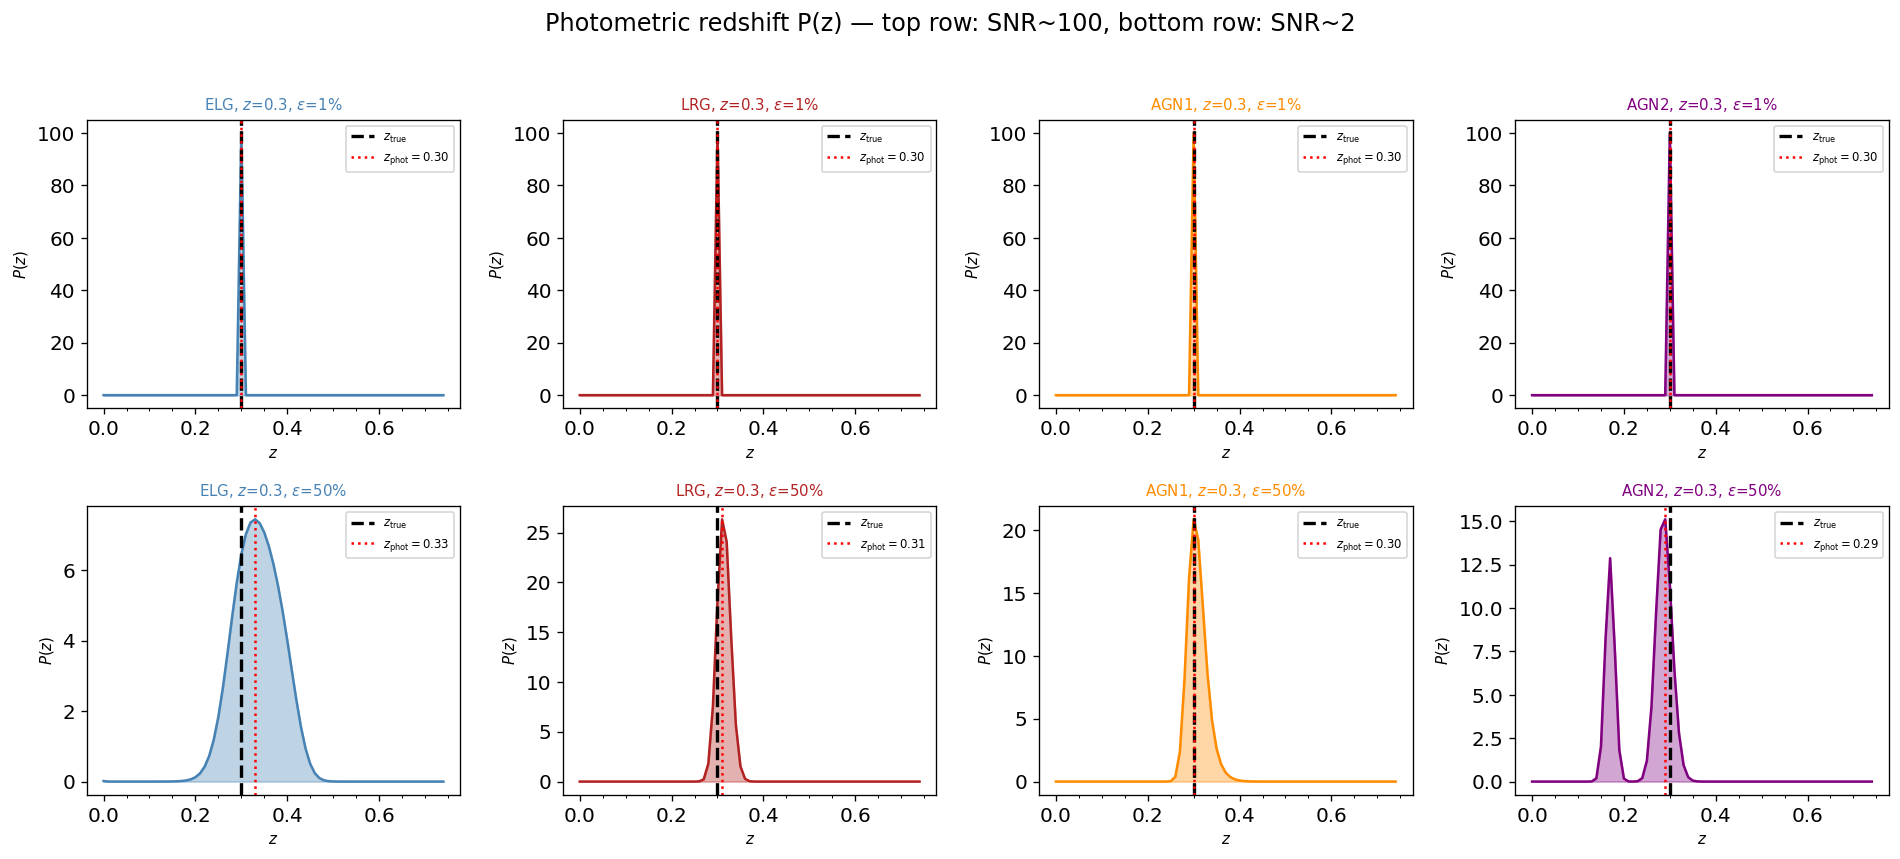

Figure saved: photoz_pz_curves.png


In [14]:
# ── P(z) plots for four representative cases ───────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

show_cases = [
    ('ELG',  0.3, 0.01),
    ('LRG',  0.3, 0.01),
    ('AGN1', 0.3, 0.01),
    ('AGN2', 0.3, 0.01),
    ('ELG',  0.3, 0.50),
    ('LRG',  0.3, 0.50),
    ('AGN1', 0.3, 0.50),
    ('AGN2', 0.3, 0.50),
]

for ax, (tkey, z_t, nl) in zip(axes.ravel(), show_cases):
    res = next(r for r in phot_results
               if r['template'] == tkey
               and r['z_true'] == z_t
               and r['noise_level'] == nl)
    color = templates[tkey]['color']
    ax.fill_between(Z_PHOT_GRID, res['pz'], alpha=0.35, color=color)
    ax.plot(Z_PHOT_GRID, res['pz'], color=color, lw=1.5)
    ax.axvline(z_t,          color='black', lw=2.0, ls='--', label='$z_{\\rm true}$')
    ax.axvline(res['z_phot'], color='red',   lw=1.5, ls=':',  label=f"$z_{{\\rm phot}}={res['z_phot']:.2f}$")
    ax.set_xlabel('$z$', fontsize=9)
    ax.set_ylabel('$P(z)$', fontsize=9)
    ax.set_title(f'{tkey}, $z$={z_t}, $\\varepsilon$={nl:.0%}', fontsize=9, color=color)
    ax.legend(fontsize=7)
    ax.xaxis.set_minor_locator(AutoMinorLocator())

plt.suptitle('Photometric redshift P(z) — top row: SNR~100, bottom row: SNR~2', y=1.02)
plt.tight_layout()
plt.savefig('photoz_pz_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: photoz_pz_curves.png')

Photometric redshift accuracy:
  ε=1%: bias=+0.0000, σ_NMAD=0.0000, η=0.0%
  ε=10%: bias=+0.0006, σ_NMAD=0.0000, η=0.0%
  ε=50%: bias=-0.0049, σ_NMAD=0.0124, η=0.0%


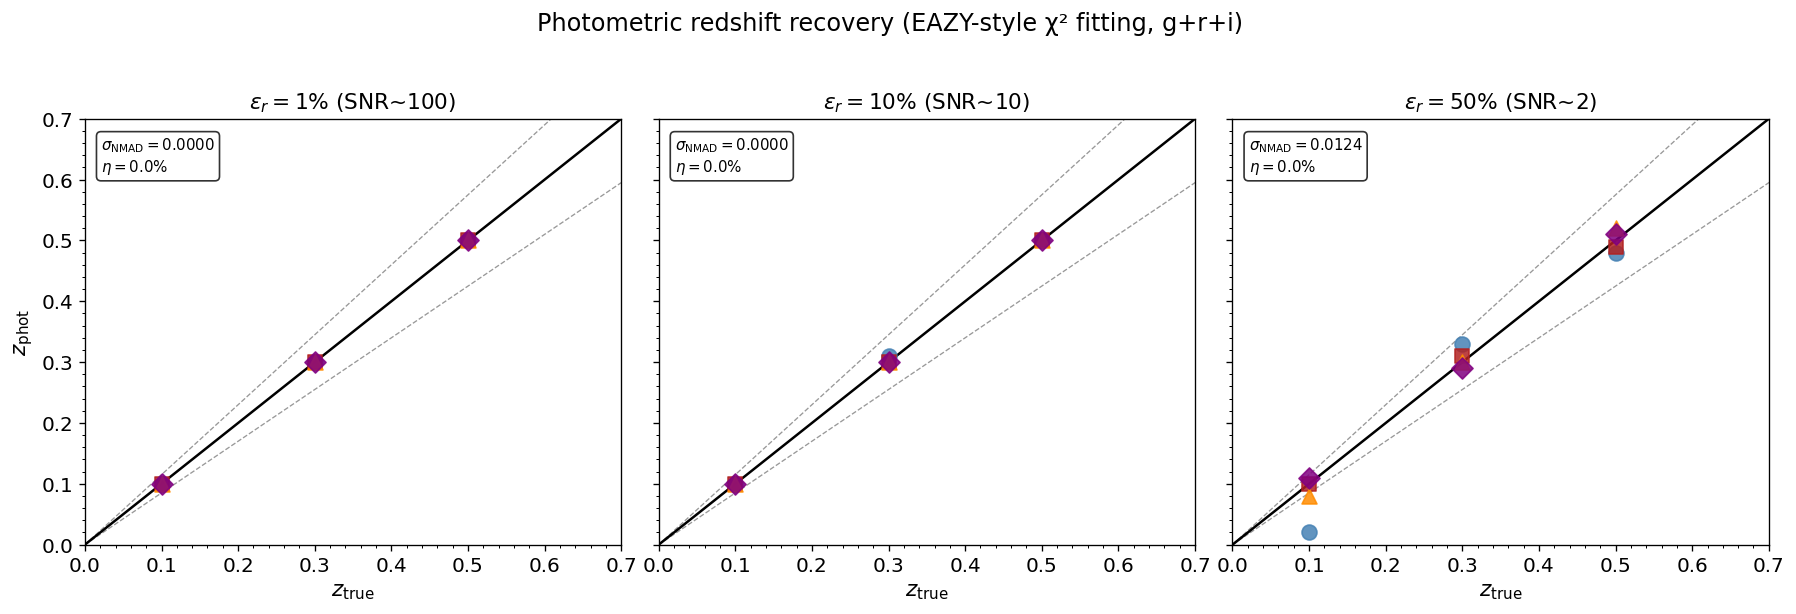

In [15]:
# ── Scatter plot: z_phot vs z_true ────────────────────────────────────────────
def photoz_metrics(dz_norm_arr, label=''):
    bias  = np.mean(dz_norm_arr)
    nmad  = 1.4826 * median_abs_deviation(dz_norm_arr)
    eta   = np.mean(np.abs(dz_norm_arr) > 0.15)
    if label:
        print(f'  {label}: bias={bias:+.4f}, σ_NMAD={nmad:.4f}, η={eta*100:.1f}%')
    return bias, nmad, eta


fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True, sharex=True)

print('Photometric redshift accuracy:')
for col, noise_level in enumerate(NOISE_LEVELS):
    ax = axes[col]
    subset = [r for r in phot_results if r['noise_level'] == noise_level]

    for res in subset:
        ax.scatter(res['z_true'], res['z_phot'],
                   color=templates[res['template']]['color'],
                   marker=markers[res['template']],
                   s=80, alpha=0.85, zorder=3)

    z_diag = [0, 0.75]
    ax.plot(z_diag, z_diag, 'k-', lw=1.5)
    ax.plot(z_diag, [z * 1.15 for z in z_diag], 'k--', lw=0.8, alpha=0.4)
    ax.plot(z_diag, [z * 0.85 for z in z_diag], 'k--', lw=0.8, alpha=0.4)
    ax.set_xlabel('$z_{\\rm true}$')
    ax.set_title(f'$\\varepsilon_r = {noise_level*100:.0f}$% (SNR~{int(1/noise_level)})')
    ax.set_xlim(0, 0.7)
    ax.set_ylim(0, 0.7)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())

    dz_norm_arr = np.array([r['dz_norm'] for r in subset])
    bias, nmad, eta = photoz_metrics(dz_norm_arr,
                                      label=f'ε={noise_level:.0%}')
    ax.text(0.03, 0.96, f'$\\sigma_{{\\rm NMAD}}={nmad:.4f}$\n$\\eta={eta*100:.1f}\\%$',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round', fc='white', alpha=0.8))

axes[0].set_ylabel('$z_{\\rm phot}$')
handles, labels_leg = axes[0].get_legend_handles_labels()
plt.suptitle('Photometric redshift recovery (EAZY-style χ² fitting, g+r+i)', y=1.02)
plt.tight_layout()
plt.savefig('photoz_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.3 Real EAZY-py on photometric data

The real `eazy-py` package requires a catalog of photometric fluxes and a template library. A minimal workflow:

```python
# pip install eazy-py
import eazy

# Initialise the photo-z object with default EAZY templates
# (downloads templates automatically on first run)
params = eazy.param.EazyParam()
params['CATALOG_FILE'] = 'my_catalog.cat'     # columns: id, z_spec, flux_g, eflux_g, ...
params['MAIN_OUTPUT_FILE'] = 'output/photoz'
params['Z_MIN']  = 0.01
params['Z_MAX']  = 3.0
params['Z_STEP'] = 0.01

photo_z = eazy.photoz.PhotoZ(param_file=None, params=params)
photo_z.fit_catalog(n_proc=4)

# Access results
z_phot  = photo_z.zgrid[photo_z.izbest]     # best-fit z
pz_arr  = photo_z.pz                        # P(z) for each galaxy
```

See the eazy-py documentation at [eazy-py.readthedocs.io](https://eazy-py.readthedocs.io) for the full API.

---

## 8. Comparison: spectroscopic vs. photometric redshifts

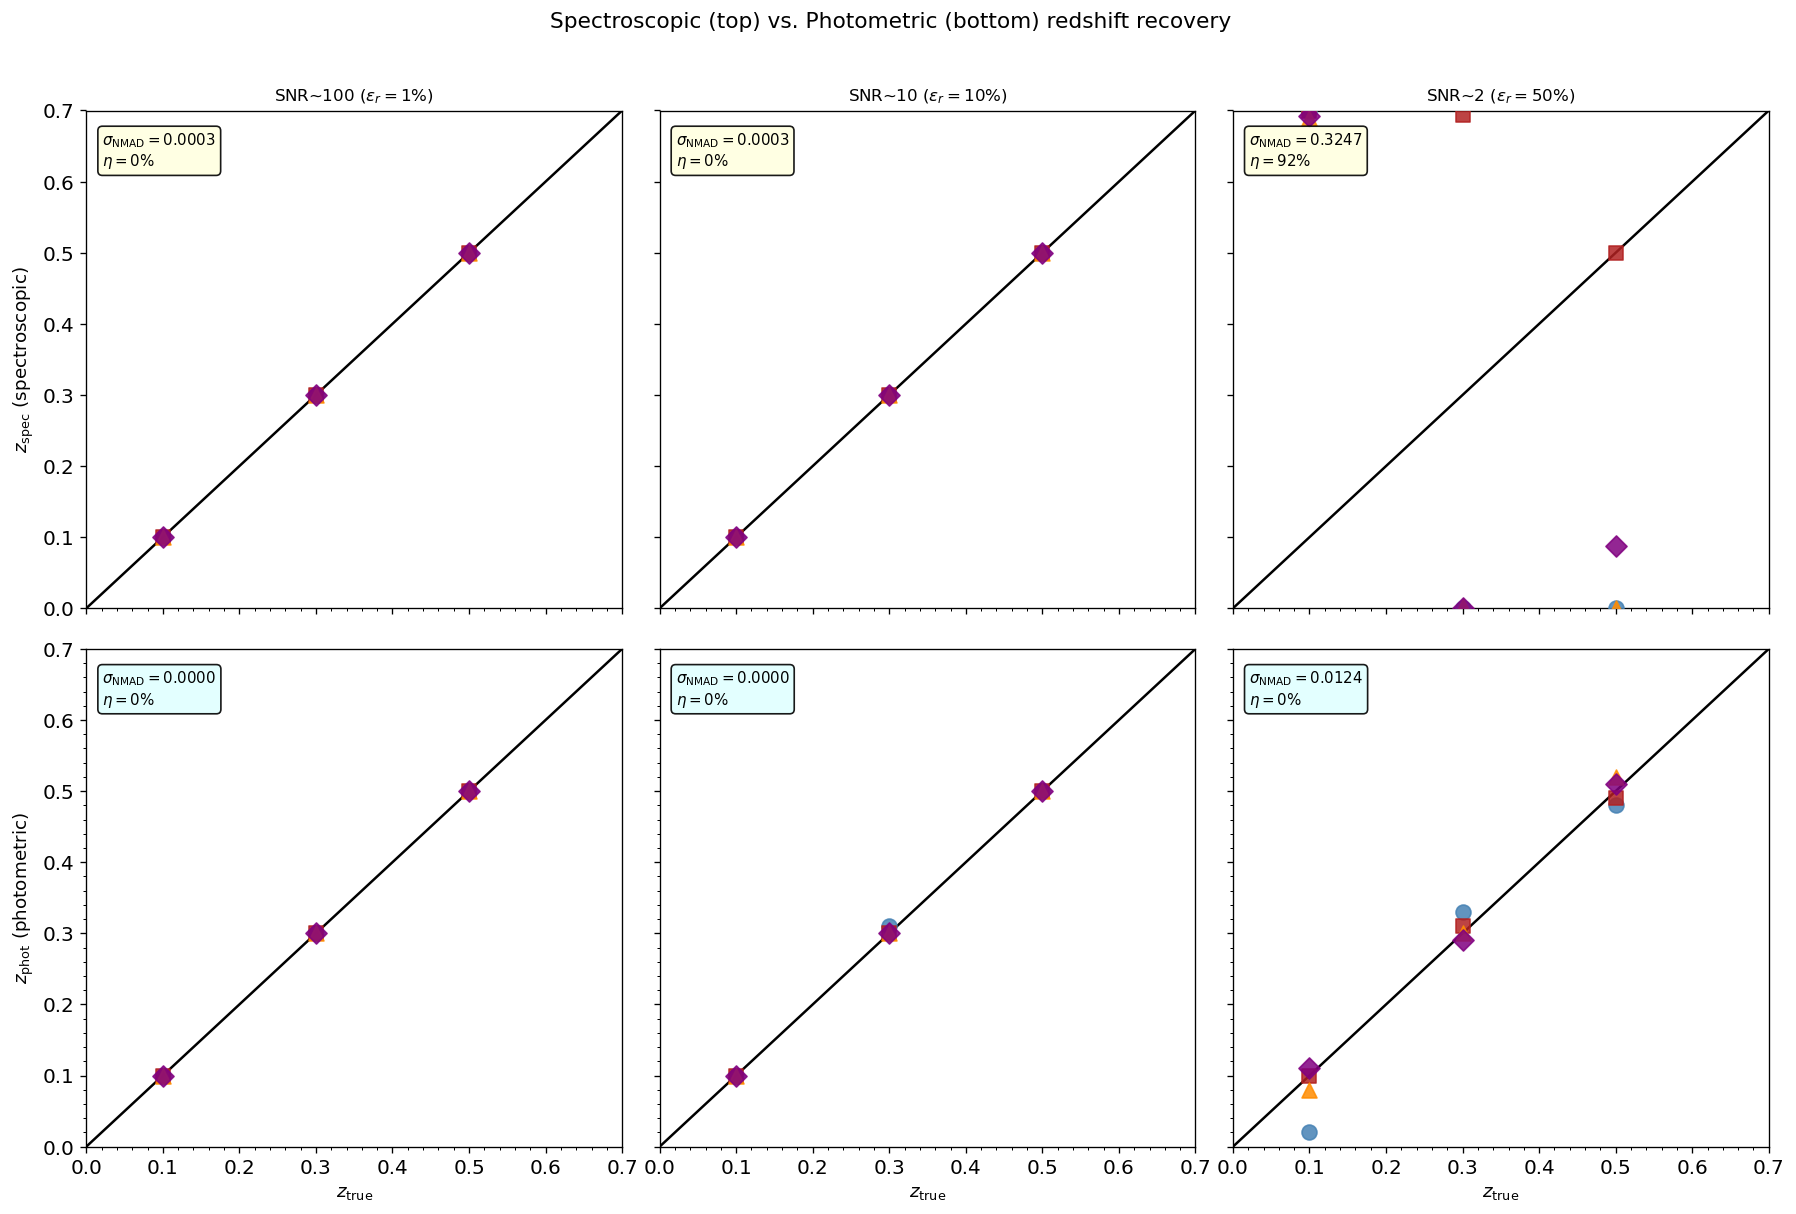

Figure saved: spec_vs_photoz_comparison.png


In [16]:
# ── Side-by-side comparison plot ──────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharey='row', sharex=True)

for col, noise_level in enumerate(NOISE_LEVELS):
    snr_label = f'SNR~{int(1/noise_level)} ($\\varepsilon_r={noise_level*100:.0f}$%)'

    # --- Spectroscopic ---
    ax = axes[0][col]
    subset_s = [r for r in spec_results if r['noise_level'] == noise_level]
    for res in subset_s:
        ax.scatter(res['z_true'], res['z_spec'],
                   color=templates[res['template']]['color'],
                   marker=markers[res['template']], s=80, alpha=0.85, zorder=3)
    ax.plot([0,0.7],[0,0.7],'k-',lw=1.5)
    ax.set_xlim(0,0.7); ax.set_ylim(0,0.7)
    ax.set_title(snr_label, fontsize=10)
    dz_s = np.array([r['dz_norm'] for r in subset_s])
    nmad_s = 1.4826 * median_abs_deviation(dz_s)
    eta_s  = np.mean(np.abs(dz_s) > 0.15)
    ax.text(0.03, 0.96,
            f'$\\sigma_{{\\rm NMAD}}={nmad_s:.4f}$\n$\\eta={eta_s*100:.0f}\\%$',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.9))
    if col == 0:
        ax.set_ylabel('$z_{\\rm spec}$ (spectroscopic)', fontsize=11)

    # --- Photometric ---
    ax = axes[1][col]
    subset_p = [r for r in phot_results if r['noise_level'] == noise_level]
    for res in subset_p:
        ax.scatter(res['z_true'], res['z_phot'],
                   color=templates[res['template']]['color'],
                   marker=markers[res['template']], s=80, alpha=0.85, zorder=3)
    ax.plot([0,0.7],[0,0.7],'k-',lw=1.5)
    ax.set_xlim(0,0.7); ax.set_ylim(0,0.7)
    ax.set_xlabel('$z_{\\rm true}$', fontsize=11)
    dz_p = np.array([r['dz_norm'] for r in subset_p])
    nmad_p = 1.4826 * median_abs_deviation(dz_p)
    eta_p  = np.mean(np.abs(dz_p) > 0.15)
    ax.text(0.03, 0.96,
            f'$\\sigma_{{\\rm NMAD}}={nmad_p:.4f}$\n$\\eta={eta_p*100:.0f}\\%$',
            transform=ax.transAxes, va='top', fontsize=9,
            bbox=dict(boxstyle='round', fc='lightcyan', alpha=0.9))
    if col == 0:
        ax.set_ylabel('$z_{\\rm phot}$ (photometric)', fontsize=11)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())

plt.suptitle('Spectroscopic (top) vs. Photometric (bottom) redshift recovery', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('spec_vs_photoz_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: spec_vs_photoz_comparison.png')

In [17]:
# ── Summary table ─────────────────────────────────────────────────────────────
print('=' * 80)
print(f'{"Method":<20} {"Noise level":>14}  {"σ_NMAD":>10} {"Outlier rate":>14}')
print('-' * 80)

for noise_level in NOISE_LEVELS:
    snr = int(1 / noise_level)
    label_noise = f'ε={noise_level:.0%} (SNR~{snr})'

    dz_s = np.array([r['dz_norm'] for r in spec_results if r['noise_level'] == noise_level])
    dz_p = np.array([r['dz_norm'] for r in phot_results if r['noise_level'] == noise_level])

    nmad_s = 1.4826 * median_abs_deviation(dz_s)
    eta_s  = np.mean(np.abs(dz_s) > 0.15)
    nmad_p = 1.4826 * median_abs_deviation(dz_p)
    eta_p  = np.mean(np.abs(dz_p) > 0.15)

    print(f'  Spectroscopic   {label_noise:>18}  {nmad_s:>10.5f} {eta_s*100:>13.1f}%')
    print(f'  Photometric     {label_noise:>18}  {nmad_p:>10.5f} {eta_p*100:>13.1f}%')
    print()

print('=' * 80)
print()
print('Key takeaways:')
print('  Spectroscopic z: excellent precision (σ_NMAD ~ 10^-3) when spectral')
print('    features are detected; fails at high noise for featureless spectra.')
print('  Photometric z: limited to σ_NMAD ~ 0.05–0.10 even at high SNR')
print('    (only 3 broad bands); degrades gracefully with noise but suffers')
print('    from colour-redshift degeneracies for red (quiescent) galaxies.')
print()
print('  In practice: DESI achieves σ_z ~ 0.0002 (1+z) at SNR > 5 per pixel.')
print('  LSST/Euclid photo-z targets σ_NMAD < 0.05 with u+g+r+i+z+Y bands.')

Method                  Noise level      σ_NMAD   Outlier rate
--------------------------------------------------------------------------------
  Spectroscopic       ε=1% (SNR~100)     0.00030           0.0%
  Photometric         ε=1% (SNR~100)     0.00000           0.0%

  Spectroscopic       ε=10% (SNR~10)     0.00030           0.0%
  Photometric         ε=10% (SNR~10)     0.00000           0.0%

  Spectroscopic        ε=50% (SNR~2)     0.32470          91.7%
  Photometric          ε=50% (SNR~2)     0.01244           0.0%


Key takeaways:
  Spectroscopic z: excellent precision (σ_NMAD ~ 10^-3) when spectral
    features are detected; fails at high noise for featureless spectra.
  Photometric z: limited to σ_NMAD ~ 0.05–0.10 even at high SNR
    (only 3 broad bands); degrades gracefully with noise but suffers
    from colour-redshift degeneracies for red (quiescent) galaxies.

  In practice: DESI achieves σ_z ~ 0.0002 (1+z) at SNR > 5 per pixel.
  LSST/Euclid photo-z targets σ_NMAD < 

---

## 9. Exercises

**Exercise 1 — Manual redshift by eye**  
Pick the ELG spectrum at z=0.3, noise level 10%. Print the observed wavelength where you expect Hα (rest 6564.6 Å) and [OII] (rest 3727.1 Å). Compute z from each line separately and compare.

**Exercise 2 — Add a u-band**  
Extend the photometric fitting to include the u-band (λ_eff = 3551 Å, FWHM = 600 Å). Recompute σ_NMAD and the outlier rate. Does a fourth band improve the photo-z quality for the LRG template?

**Exercise 3 — Look-back time**  
Using `astropy.cosmology.FlatLambdaCDM(H0=70, Om0=0.3)`, compute the look-back time and comoving distance for each of the three redshifts z = [0.1, 0.3, 0.5]. At what fraction of the age of the universe are we observing each galaxy?

**Exercise 4 — Colour–redshift degeneracy**  
Find all cases where the photometric redshift is a catastrophic failure (|Δz/(1+z)| > 0.15). For each case, plot g−r vs r−i for the true galaxy and the confused (z, template) combination. Explain why the two objects have similar colours despite different redshifts.

**Exercise 5 — Bayesian prior on redshift**  
Modify the `photoz_chi2_grid` function to include a Gaussian prior $\pi(z) \propto \exp[-(z-0.3)^2 / (2\times 0.2^2)]$ centred at z = 0.3. Recompute all photo-z estimates and check whether the prior reduces catastrophic failures at the cost of biasing the estimates.

---

## References

- **Brammer, van Dokkum & Coppi** (2008), ApJ 686, 1503 — EAZY photo-z code. [arXiv:0807.1533](https://arxiv.org/abs/0807.1533)
- **Bolzonella, Miralles & Pelló** (2000), A&A 363, 476 — BPZ template fitting. [arXiv:astro-ph/0003380](https://arxiv.org/abs/astro-ph/0003380)
- **Guy et al.** (2023), AJ 165, 144 — DESI spectroscopic data processing pipeline (redrock). [arXiv:2209.01384](https://arxiv.org/abs/2209.01384)
- **DESI Collaboration, Adame et al.** (2023) — DESI EDR overview. [arXiv:2306.06308](https://arxiv.org/abs/2306.06308)
- **Comparat et al.** (2020) — qmost spectral templates. [github.com/JohanComparat/qmost_templates](https://github.com/JohanComparat/qmost_templates)
- **Laigle et al.** (2016), ApJS 224, 24 — COSMOS2015 photo-z catalog. [arXiv:1604.02350](https://arxiv.org/abs/1604.02350)
- **Hogg, Baldry, Blanton & Eisenstein** (2002) — K corrections. [arXiv:astro-ph/0210394](https://arxiv.org/abs/astro-ph/0210394)
- eazy-py documentation: [eazy-py.readthedocs.io](https://eazy-py.readthedocs.io)
- DESI data documentation: [data.desi.lbl.gov/doc/](https://data.desi.lbl.gov/doc/)
- DESI tutorials: [github.com/desihub/tutorials](https://github.com/desihub/tutorials)